In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# ── 한글 폰트 설정 ──────────────────────────────────────────
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux (Colab 등)
    # 나눔고딕 설치
    import subprocess
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    fm._load_fontmanager(try_read_cache=False)
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# ── 1. 데이터 로드 ──────────────────────────────────────────
df = pd.read_csv('./data/Mall_Customers.csv')

print("shape:", df.shape)
print(df.head())
print("\n결측치:\n", df.isnull().sum())
print("\ndtypes:\n", df.dtypes)

# ── 2. 전처리 ───────────────────────────────────────────────

# (1) 불필요한 컬럼 제거 (CustomerID는 식별자라 분석에 불필요)
df = df.drop(columns=['CustomerID'])

# (2) 범주형 변수 인코딩 (Gender: Male→1, Female→0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])   # Female=0, Male=1

# (3) 결측치 처리 (수치형: 중앙값, 범주형: 최빈값)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

# (4) 컬럼명 정리 (공백·특수문자 제거)
df.columns = (df.columns
                .str.strip()
                .str.replace(r'[\s\(\)\$]', '_', regex=True)
                .str.replace(r'_+', '_', regex=True)
                .str.strip('_'))

print("\n전처리 후 컬럼명:", df.columns.tolist())
print(df.head())

# ── 3. 스케일링 ─────────────────────────────────────────────
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print("\n스케일링 후 기초통계:\n", df_scaled.describe().round(2))

# ── 4. PCA 준비 (df_scaled → PCA 입력용) ────────────────────
# df      : 전처리 완료된 원본 스케일 데이터프레임
# df_scaled: StandardScaler 적용된 PCA 입력용 데이터프레임

print("\n✅ df 저장 완료! shape:", df.shape)
print("✅ df_scaled 저장 완료! shape:", df_scaled.shape)

shape: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

결측치:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

dtypes:
 CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

전처리 후 컬럼명: ['Gender', 'Age', 'Annual_Income_k', 'Spending_Score_1-100']
   Gender  Age  Annual_Income_k  Spending_Score_1-100
0       1   19               15                    39
1       1   21               15  

In [5]:
df_scaled

,Gender,Age,Annual_Income_k,Spending_Score_1-100
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980
...,...,...,...,...
195,-0.886405,-0.276302,2.268791,1.118061
196,-0.886405,0.441365,2.497807,-0.861839
197,1.128152,-0.491602,2.497807,0.923953
198,1.128152,-0.491602,2.917671,-1.250054


  PC1 설명력 : 33.69%
  PC2 설명력 : 26.23%
  누적 설명력 : 59.92%

📌 변수별 주성분 기여도 (Loadings):
                        PC1    PC2
Gender                0.234  0.627
Age                   0.688 -0.104
Annual_Income_k      -0.006  0.765
Spending_Score_1-100 -0.687  0.103


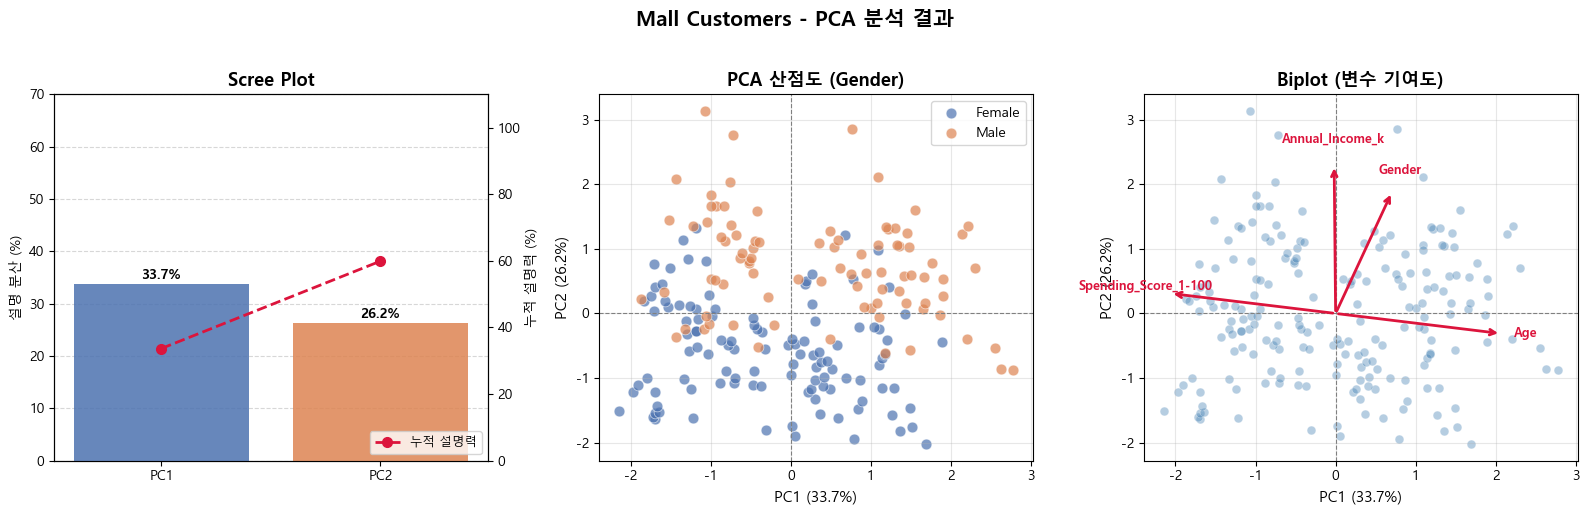


✅ 그래프 저장 완료: pca_result.png


In [9]:
# ── 5. PCA (주성분 2개) ─────────────────────────────────────
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

# 주성분 데이터프레임
df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

# ── 6. 설명력 확인 ──────────────────────────────────────────
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("=" * 45)
print(f"  PC1 설명력 : {explained_var[0]*100:.2f}%")
print(f"  PC2 설명력 : {explained_var[1]*100:.2f}%")
print(f"  누적 설명력 : {cumulative_var[1]*100:.2f}%")
print("=" * 45)

# 각 변수의 주성분 기여도 (Loadings)
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_scaled.columns,
    columns=['PC1', 'PC2']
)
print("\n📌 변수별 주성분 기여도 (Loadings):")
print(loadings.round(3))

# ── 7. 시각화 ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 3, figure=fig)

# ── (1) Scree Plot (설명력 막대+누적선) ──
ax1 = fig.add_subplot(gs[0])
components = [f'PC{i+1}' for i in range(len(explained_var))]
bars = ax1.bar(components, explained_var * 100, color=['#4C72B0', '#DD8452'], alpha=0.85, zorder=3)
ax2_twin = ax1.twinx()
ax2_twin.plot(components, cumulative_var * 100, 'o--', color='crimson', linewidth=2, markersize=7, label='누적 설명력')
ax2_twin.set_ylabel('누적 설명력 (%)', fontsize=10)
ax2_twin.set_ylim(0, 110)
for bar, val in zip(bars, explained_var * 100):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Scree Plot', fontsize=13, fontweight='bold')
ax1.set_ylabel('설명 분산 (%)', fontsize=10)
ax1.set_ylim(0, 70)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax2_twin.legend(loc='lower right', fontsize=9)

# ── (2) PCA 산점도 (Gender 색상 구분) ──
ax3 = fig.add_subplot(gs[1])
colors = {0: '#4C72B0', 1: '#DD8452'}
labels = {0: 'Female', 1: 'Male'}
for gender_val in [0, 1]:
    mask = df['Gender'] == gender_val
    ax3.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                c=colors[gender_val], label=labels[gender_val],
                alpha=0.7, s=60, edgecolors='white', linewidths=0.5)
ax3.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)', fontsize=11)
ax3.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)', fontsize=11)
ax3.set_title('PCA 산점도 (Gender)', fontsize=13, fontweight='bold')
ax3.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax3.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

# ── (3) Biplot (변수 기여도 화살표) ──
ax4 = fig.add_subplot(gs[2])
ax4.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.4, s=40, color='steelblue', edgecolors='white', linewidths=0.5)
scale = 3.0
for i, var in enumerate(loadings.index):
    ax4.annotate('', xy=(loadings.iloc[i, 0]*scale, loadings.iloc[i, 1]*scale), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='crimson', lw=2))
    ax4.text(loadings.iloc[i, 0]*scale*1.15, loadings.iloc[i, 1]*scale*1.15,
             var, fontsize=9, color='crimson', fontweight='bold', ha='center')
ax4.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)', fontsize=11)
ax4.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)', fontsize=11)
ax4.set_title('Biplot (변수 기여도)', fontsize=13, fontweight='bold')
ax4.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax4.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax4.grid(alpha=0.3)

plt.suptitle('Mall Customers - PCA 분석 결과', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pca_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ 그래프 저장 완료: pca_result.png")

In [10]:
# ── 전체 주성분 설명력 확인 ─────────────────────────────────
pca_full = PCA(n_components=None)  # 전체 주성분 계산
pca_full.fit(df_scaled)

ev = pca_full.explained_variance_ratio_
cum_ev = np.cumsum(ev)
eigenvalues = pca_full.explained_variance_  # 고유값

print("=" * 50)
print(f"{'PC':<6} {'설명력':>8} {'누적 설명력':>12} {'고유값(eigenvalue)':>18}")
print("-" * 50)
for i, (e, c, eig) in enumerate(zip(ev, cum_ev, eigenvalues)):
    marker = " ✅" if eig >= 1.0 else " ❌"
    print(f"PC{i+1:<4} {e*100:>7.2f}%  {c*100:>10.2f}%   {eig:>10.3f}{marker}")
print("=" * 50)
print(f"\n📌 Kaiser 기준(고유값 ≥ 1) 충족 PC 개수: {sum(eigenvalues >= 1)}개")
print(f"📌 70% 설명력 달성 최소 PC 개수     : {next(i+1 for i, c in enumerate(cum_ev) if c >= 0.70)}개")
print(f"📌 80% 설명력 달성 최소 PC 개수     : {next(i+1 for i, c in enumerate(cum_ev) if c >= 0.80)}개")

PC          설명력       누적 설명력    고유값(eigenvalue)
--------------------------------------------------
PC1      33.69%       33.69%        1.354 ✅
PC2      26.23%       59.92%        1.054 ✅
PC3      23.26%       83.18%        0.935 ❌
PC4      16.82%      100.00%        0.676 ❌

📌 Kaiser 기준(고유값 ≥ 1) 충족 PC 개수: 2개
📌 70% 설명력 달성 최소 PC 개수     : 3개
📌 80% 설명력 달성 최소 PC 개수     : 3개
